# Example of manipulation a survey using the SurveyAcessor
O. Kaufmann, 2024-2025.

In [1]:
from geometron.survey import TopoPoint, TopoLine, TopoObject
from geometron.geometries import features_to_gdf, gdf_to_features
from geometron.survey.survey import create_survey, SurveyAccessor
from shapely import Point, LineString
import numpy as np

In [2]:
import geopandas as gpd
gdf = gpd.read_file('./data/20220323_Radon_ft4.gpkg')
gdf.set_index('id', inplace=True)

In [3]:
gdf

,label,kind,class,geometry
id,,,,
L059,L059,landmark,TopoPoint,POINT (608789.06 623078.416)
L060,L060,landmark,TopoPoint,POINT (608772.729 623067.047)
L061,L061,landmark,TopoPoint,POINT (608752.322 623045.075)
L079,L079,landmark,TopoPoint,POINT (608761.872 623045.075)
L080,L080,landmark,TopoPoint,POINT (608770.773 623020.206)
L081,L081,landmark,TopoPoint,POINT (608777.011 623009.458)
L082,L082,landmark,TopoPoint,POINT (608777.716 622997.993)
L083,L083,landmark,TopoPoint,POINT (608773.121 622987.598)
L084,L084,landmark,TopoPoint,POINT (608768.09 622976.299)


In [4]:
gdf['show_label'] = True
gdf['show_label'] = gdf.show_label.astype('boolean')
gdf.crs = 'epsg:3812'

In [5]:
gdf.survey.method = 'radon'
gdf.survey.name = '2022_ft4_radon'
gdf.survey.add_field_log('./data/20220323_ft4_Radon.pdf')

## Add missing stations on landmarks

In [6]:
stations = []
for idx, row in gdf.iterrows():
    if row['kind'] == 'landmark':
        station_idx = idx.replace('L', 'S')
        stations.append(TopoPoint(row['geometry'], id=station_idx, kind='station'))
gdf = gdf.survey.add_features(stations)
#gdf.survey._gdf.loc[gdf.survey.stations.index,'show_label'] = False

/home/su530201/.local/share/virtualenvs/geometron-VhFx4lLH/lib/python3.10/site-packages/geopandas/array.py:1638: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as ETRS89 / Belgian Lambert 2008 (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))


## Plot stations

<Axes: >

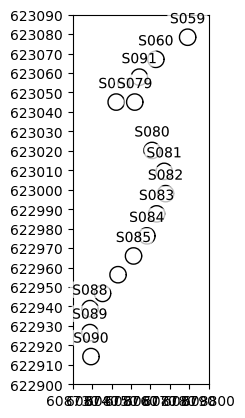

In [7]:
gdf.survey.stations.survey.plot()

## Display field log

In [8]:
gdf.survey.field_log

## Add a stake in the Survey

In [9]:
gdf=gdf.survey.add_features([TopoPoint('POINT (608760.0 623020)', id='K001', kind='stake')])

/home/su530201/.local/share/virtualenvs/geometron-VhFx4lLH/lib/python3.10/site-packages/geopandas/array.py:1638: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as ETRS89 / Belgian Lambert 2008 (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))


### Hide stakes and landmarks labels

## Plot a survey map

In [12]:
idx = gdf.query('kind=="stake" or kind=="landmark"').index
gdf.loc[idx, 'show_label'] = False

<Axes: >

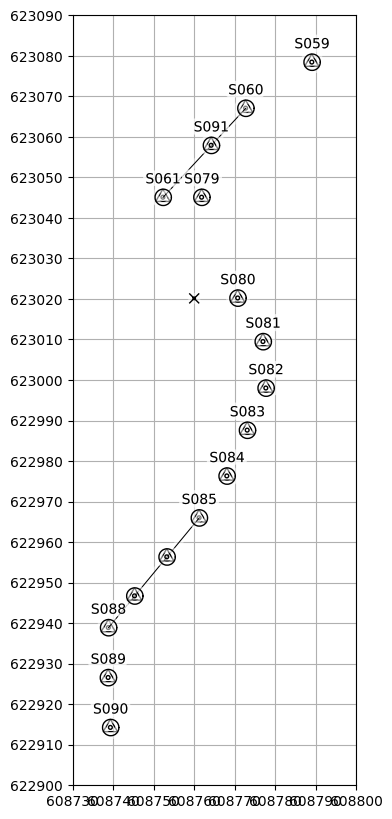

In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,10))
gdf.survey.plot(ax=ax, grid='on')

# Save the survey

In [14]:
gdf.survey.save()

filename: 2022_ft4_radon_survey, tmp_dir: ._tmp_survey/, field log: ./data/20220323_ft4_Radon.pdf


## Convert the survey to features

In [15]:
features, crs = gdf.survey.to_features()

feature properties: {'label': 'L059', 'kind': 'landmark', 'class': 'TopoPoint', 'show_label': False, 'id': 'L059'}
feature properties: {'label': 'L060', 'kind': 'landmark', 'class': 'TopoPoint', 'show_label': False, 'id': 'L060'}
feature properties: {'label': 'L061', 'kind': 'landmark', 'class': 'TopoPoint', 'show_label': False, 'id': 'L061'}
feature properties: {'label': 'L079', 'kind': 'landmark', 'class': 'TopoPoint', 'show_label': False, 'id': 'L079'}
feature properties: {'label': 'L080', 'kind': 'landmark', 'class': 'TopoPoint', 'show_label': False, 'id': 'L080'}
feature properties: {'label': 'L081', 'kind': 'landmark', 'class': 'TopoPoint', 'show_label': False, 'id': 'L081'}
feature properties: {'label': 'L082', 'kind': 'landmark', 'class': 'TopoPoint', 'show_label': False, 'id': 'L082'}
feature properties: {'label': 'L083', 'kind': 'landmark', 'class': 'TopoPoint', 'show_label': False, 'id': 'L083'}
feature properties: {'label': 'L084', 'kind': 'landmark', 'class': 'TopoPoint', 

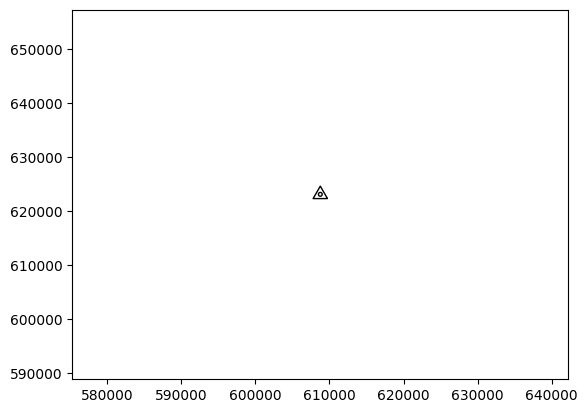

In [16]:
features[0].plot()

## Copy a survey

In [17]:
gdf_copy = gdf.survey.copy()
gdf_copy.survey.name

'2022_ft4_radon'

## Use indexing to retrieve a feature

In [18]:
B01_copy, crs = gdf.survey['B01']
crs

feature properties: {'label': '', 'kind': 'baseline', 'class': 'TopoLine', 'show_label': True, 'id': 'B01'}


<Projected CRS: EPSG:3812>
Name: ETRS89 / Belgian Lambert 2008
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: Belgium - onshore.
- bounds: (2.5, 49.5, 6.4, 51.51)
Coordinate Operation:
- name: Belgian Lambert 2008
- method: Lambert Conic Conformal (2SP)
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

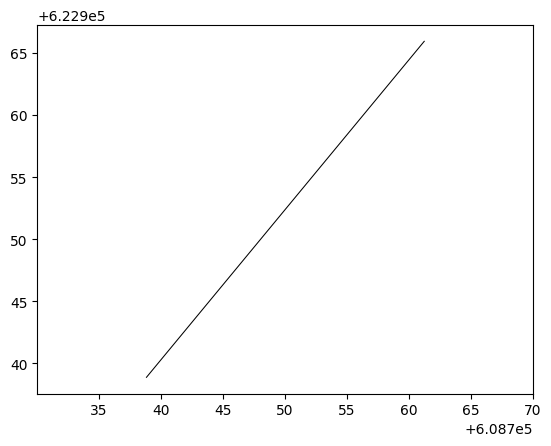

In [19]:
B01_copy.show_label=True
B01_copy.plot()

## Add missing label

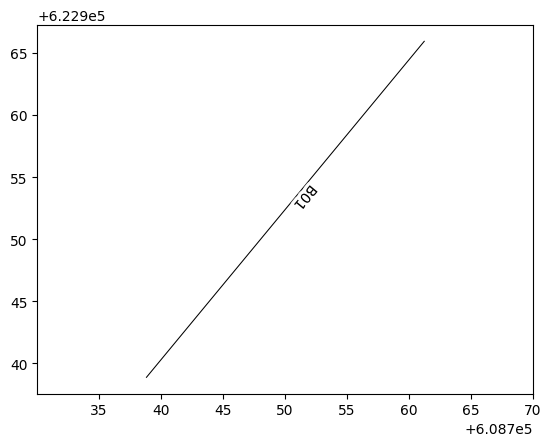

In [21]:
B01_copy.label = 'B01'
B01_copy.plot()

## Change survey CRS

In [22]:
gdf_copy.to_crs('epsg:31370', inplace=True)

<Axes: >

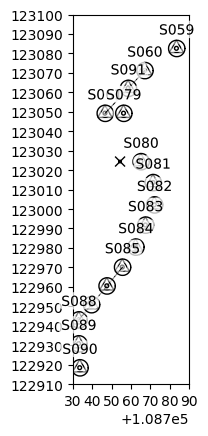

In [23]:
gdf_copy.survey.plot()